**MAESTRÍA EN ECONOMÍA APLICADA - UBA 2025**
**TALLER DE PROGRAMACIÓN**
**GRUPO 2**

In [1]:
# Carga de usuario para simplificar paths de acceso según quién ejecute el código
print("Ingrese su número de referencia de usuario de la lista\nAlvarez - 1\nGodino - 2\nSulca - 3\nOtro usuario - 4:")
usuario = input("Ingrese su número de referencia de usuario de la lista\nAlvarez - 1\nGodino - 2\nSulca - 3\nOtro usuario - 4:")
if usuario == '1':
    nombre = "Alvarez"
    path = "C:\\Users\\marti\\OneDrive\\Documentos\\"
elif usuario == '2':
    nombre = "Alvarez"
    path = "C:\\Users\\Usuario\\Documents\\"
elif usuario == '3':
    nombre = "Alvarez"
    path = "C:\\Users\\user\\Documents\\"
elif usuario == '4':
    print("A modo de ejemplo, el path a la carpeta Github debe tener esta forma: C:\\Users\\Usuario\\Documents\\")
    path = input("Ingrese el path en su computadora a la carpeta Github: ")
print(f"Path cargado correctamente")

Ingrese su número de referencia de usuario de la lista
Alvarez - 1
Godino - 2
Sulca - 3
Otro usuario - 4:
Path cargado correctamente


# TP1

In [2]:
# Librerías a utilizar
# !pip install openpyxl - utilizar en caso no te cargue el archivo de excel
import pandas as pd
import numpy as np
import seaborn as sns   
import matplotlib.pyplot as plt

In [3]:
# Carga de datos de individuos de la EPH 1T2005-1T2025
T105_original = pd.read_stata(path+"GitHub\\Big-Data-UBA--Grupo-2\\base de datos\\usu_individual_T105.dta",convert_categoricals=False)
T125_original = pd.read_excel(path+"GitHub\\Big-Data-UBA--Grupo-2\\base de datos\\usu_individual_T125.xlsx")


In [4]:
# Carga de datos de hogares de la EPH 1T2005-1T2025 (para parte 1.d, que es opcional)
H105_original = pd.read_stata(path+"GitHub\\Big-Data-UBA--Grupo-2\\base de datos\\Hogar_T105.dta",convert_categoricals=False)
H125_original = pd.read_excel(path+"GitHub\\Big-Data-UBA--Grupo-2\\base de datos\\usu_hogar_T125.xlsx")

## PARTE 1

### 2.a: Selección de región y fusión de bases

In [5]:
# Seleccion de variables de interes
select_var_T105 = ["CODUSU", "nro_hogar", "ch03", "ch04", "ch06", "ch07", "ch08", "nivel_ed", "estado", "cat_inac", "ipcf",
                   "cat_ocup", "pp03c", "pp03i", "pp10a", "p21", "tot_p12", "t_vi","itf","ch12", "ch13", "ch14", "pp3e_tot", "pp3f_tot"]
select_var_T125 = ["CODUSU", "NRO_HOGAR", "CH03", "CH04", "CH06", "CH07", "CH08", "NIVEL_ED", "ESTADO", "CAT_INAC", "IPCF",
                   "CAT_OCUP", "PP03C", "PP03I", "PP10A", "P21", "TOT_P12", "T_VI","ITF","CH12", "CH13", "CH14", "PP3E_TOT", "PP3F_TOT"]

# Actualizamos nuestro dataframe con las variables seleccionadas y la región seleccionada Noroeste = NOA = 40
T105 = T105_original[T105_original['region'] == 40][select_var_T105]
T125 = T125_original[T125_original['REGION'] == 40][select_var_T125]

# Homogeneizamos los nombres de las columnas para poder fusionarlas más adelante
column_mapping = dict(zip(select_var_T125, select_var_T105)) # diccionario
T125 = T125.rename(columns=column_mapping) # renombramos

In [6]:
# Antes de proceder con la unión de ambas bases, verificamos que ambas tengan el mismo tipo de dato.
T105.info()
T125.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9348 entries, 9484 to 18831
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CODUSU     9348 non-null   object 
 1   nro_hogar  9348 non-null   float64
 2   ch03       9348 non-null   float64
 3   ch04       9348 non-null   float64
 4   ch06       9348 non-null   float64
 5   ch07       9348 non-null   float64
 6   ch08       9348 non-null   float64
 7   nivel_ed   9348 non-null   float64
 8   estado     9348 non-null   float64
 9   cat_inac   9348 non-null   float64
 10  ipcf       9348 non-null   float64
 11  cat_ocup   9348 non-null   float64
 12  pp03c      9348 non-null   float64
 13  pp03i      9348 non-null   float64
 14  pp10a      9348 non-null   float64
 15  p21        9348 non-null   float64
 16  tot_p12    9348 non-null   float64
 17  t_vi       9348 non-null   float64
 18  itf        9348 non-null   float64
 19  ch12       9348 non-null   float64
 20  ch13     

In [7]:
# Ajustamos valores nulos
for df in [T105, T125]:
    df["ch06"] = df["ch06"].replace(-1,0) # Edad
    df["estado"] = df["estado"].replace(0,np.nan) # Condición de actividad
    df["cat_inac"] = df["cat_inac"].replace(0,np.nan) # Categoría de inactividad
    df["cat_ocup"] = df["cat_ocup"].replace(0,np.nan) # Categoría de ocupación
    df["pp03c"] = df["pp03c"].replace(0,np.nan)
    df["pp03i"] = df["pp03i"].replace(0,np.nan).replace(9,np.nan)
    df["pp10a"] = df["pp10a"].replace(0,np.nan)
    df["p21"] = df["p21"].replace(0,np.nan).replace(-9,np.nan)
    df["tot_p12"] = df["tot_p12"].replace(0,np.nan)
    df["t_vi"] = df["t_vi"].replace(0,np.nan)
    df["ipcf"] = df["ipcf"].replace(0,np.nan)
    df["itf"] = df["itf"].replace(0,np.nan)

### 2.b: Revisión de formato

In [8]:
# # Ajustamos el Dtype para ambas bases
# categóricas = ["ch04","ch06","ch07","ch08","nivel_ed","estado","cat_inac", "cat_ocup", "pp03c","pp03i","pp10a"]
# T105[categóricas] = T105[categóricas].astype('int64')
# T125["ch08"] = T125["ch08"].astype('int64')

# Creamos columna para identificar los df
T105['df'] = 'T105'
T125['df'] = 'T125'

# Fusionamos los archivos
eph_105_125 = pd.concat([T105, T125], ignore_index=True)
eph_105_125.sample(6)


,CODUSU,nro_hogar,ch03,ch04,ch06,ch07,ch08,nivel_ed,estado,cat_inac,...,p21,tot_p12,t_vi,itf,ch12,ch13,ch14,pp3e_tot,pp3f_tot,df
3100,139059,3.0,1.0,1.0,23.0,1.0,4.0,3.0,1.0,NaN,...,700.0,NaN,NaN,700.0,4.0,2.0,01,72.0,0.0,T105
13620,TQRMNOPSTHJOLOCDEHLEH00875559,1.0,2.0,2.0,83.0,2.0,1.0,2.0,3.0,7.0,...,NaN,NaN,250000.0,650000.0,2.0,1.0,NaN,NaN,NaN,T125
5793,128387,1.0,1.0,1.0,53.0,2.0,1.0,2.0,1.0,NaN,...,300.0,NaN,600.0,1300.0,2.0,1.0,,48.0,0.0,T105
15763,TQRMNORRQHJOLQCDEGOIH00874556,2.0,1.0,2.0,45.0,5.0,4.0,2.0,1.0,NaN,...,370000.0,NaN,232000.0,1518000.0,2.0,1.0,NaN,20.0,0.0,T125
15081,TQRMNOPTXHLNLOCDEGPDJ00853580,1.0,1.0,2.0,51.0,3.0,3.0,4.0,1.0,NaN,...,80000.0,NaN,295000.0,735000.0,4.0,1.0,NaN,4.0,0.0,T125
13477,TQRMNORUYHJMLMCDEHLEH00873951,1.0,5.0,2.0,22.0,5.0,1.0,4.0,1.0,NaN,...,300000.0,NaN,NaN,1640000.0,4.0,1.0,NaN,20.0,0.0,T125


In [9]:
# Procedemos a revisar las variables que tenemos, exceptuando las variables de identificación
eph_105_125.drop("nro_hogar", axis=1).describe()

,ch03,ch04,ch06,ch07,ch08,nivel_ed,estado,cat_inac,ipcf,cat_ocup,...,pp03i,pp10a,p21,tot_p12,t_vi,itf,ch12,ch13,pp3e_tot,pp3f_tot
count,19090.000000,19090.000000,19090.000000,19090.000000,19090.000000,19090.000000,19066.000000,10623.000000,1.797300e+04,8285.000000,...,7761.000000,676.000000,7.119000e+03,1.149000e+03,4.026000e+03,1.797300e+04,19090.000000,19090.000000,13701.000000,13701.000000
mean,2.727763,1.518491,32.668465,3.728392,2.731011,3.632635,2.303997,3.406947,1.995711e+05,2.742547,...,1.810463,2.939349,3.173427e+05,1.516537e+05,2.591888e+05,7.125992e+05,3.795809,1.465898,18.932852,0.753157
std,1.719837,0.499671,21.527467,1.583989,2.411227,1.858963,1.155428,1.418128,3.194798e+05,0.538460,...,0.391960,1.509728,4.453888e+05,2.749388e+05,3.453418e+05,1.015200e+06,1.994125,0.610656,22.405732,3.874521
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000e+00,1.000000,...,1.000000,1.000000,7.000000e+00,-9.000000e+00,-9.000000e+00,1.000000e+01,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,15.000000,2.000000,1.000000,2.000000,1.000000,3.000000,1.750000e+02,3.000000,...,2.000000,2.000000,4.200000e+02,1.500000e+02,6.150000e+02,8.500000e+02,2.000000,1.000000,0.000000,0.000000
50%,3.000000,2.000000,29.000000,5.000000,2.000000,4.000000,3.000000,3.000000,1.033333e+03,3.000000,...,2.000000,2.000000,1.500000e+05,1.500000e+03,1.800000e+05,3.750000e+03,4.000000,2.000000,7.000000,0.000000
75%,3.000000,2.000000,48.000000,5.000000,4.000000,5.000000,3.000000,4.000000,3.145714e+05,3.000000,...,2.000000,5.000000,5.000000e+05,2.000000e+05,3.700000e+05,1.200000e+06,5.000000,2.000000,40.000000,0.000000
max,10.000000,2.000000,103.000000,5.000000,23.000000,7.000000,4.000000,7.000000,6.150000e+06,4.000000,...,2.000000,5.000000,7.000000e+06,2.700000e+06,4.500000e+06,1.230000e+07,9.000000,2.000000,126.000000,63.000000


En base a esta tabla y al diseño del cuestionario de la EPH y detectamos que:

* CH06 (edad): existencia de valores negativos, que representa menores de un año
* CH08 (cobertura médica): 9 implica no respuesta
* CAT_INAC (categoria de inactividad): presenta 0, lo que es una señal de que no aplica esta pregunta para esa persona
* CAT_OCUP (categoria de actividad): presenta 0, lo que es una señal de que no aplica esta pregunta para esa persona
* ESTADO (condición de actividad): presenta 0, que implica no respuesta
* PP03C (empleo semana anterior): presenta 0, lo que es una señal de que no aplica esta pregunta para esa persona
* PP03I (buscó trabajo en el último mes): presenta 0, lo que es una señal de que no aplica esta pregunta para esa persona, y también 9, que es no responde
* PP10A (cuanto hace que busca empleo): presenta 0, lo que es una señal de que no aplica esta pregunta para esa persona, y también 9, que es no responde
* P21, TOT_P12 y T_VI, que son ingresos: presentan -9, indicativo de no respuesta

### 2.c: Corrección de datos y heatmap

In [10]:
# Correcciones de datos
eph_105_125['ch06'] = eph_105_125['ch06'].replace(-1, 0) # Menores de 1 año
eph_105_125['ch08'] = eph_105_125['ch08'].replace(9, np.nan) # No sabe/No responde en cobertura médica
eph_105_125['estado'] = eph_105_125['estado'].replace(0, np.nan) # No responde estado de actividad
eph_105_125['p21'] = eph_105_125['p21'].replace(-9, np.nan) # No respuesta en ingreso ocupación principal
eph_105_125['tot_p12'] = eph_105_125['tot_p12'].replace(-9, np.nan) # No respuesta en ingreso otras ocupaciones
eph_105_125['t_vi'] = eph_105_125['t_vi'].replace(-9, np.nan) # No respuesta en total ingreso no laboral

# Se opta por no modificar los datos que implican no aplica, dado que representa una diferencia cualitativa y no un faltante de datos

In [11]:
# Revisamos los valores faltantes
eph_105_125.isna().sum()

CODUSU           0
nro_hogar        0
ch03             0
ch04             0
ch06             0
ch07             0
ch08            15
nivel_ed         0
estado          24
cat_inac      8467
ipcf          1117
cat_ocup     10805
pp03c        12034
pp03i        11329
pp10a        18414
p21          11971
tot_p12      17985
t_vi         15172
itf           1117
ch12             0
ch13             0
ch14          4836
pp3e_tot      5389
pp3f_tot      5389
df               0
dtype: int64

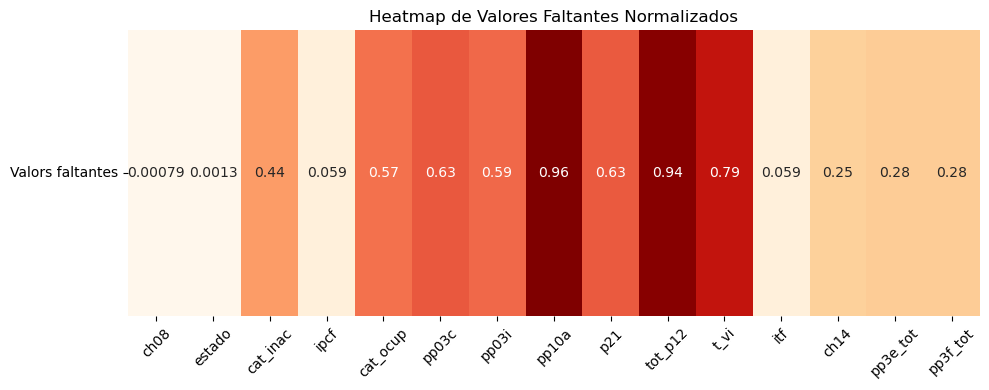

In [12]:
# Generamos el recuento de valores vacios
missing_counts = eph_105_125.isna().sum()
missing_counts = missing_counts[missing_counts > 0]

# Normalizar los valores faltantes para mejorar la visibilidad
normalized_missing = missing_counts / eph_105_125.shape[0]  # Normalizamos por el total de filas
missing_df = pd.DataFrame(normalized_missing, columns=['Valors faltantes'])

# Crear el heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(missing_df.transpose(), annot=True, cmap='OrRd', cbar=False)
plt.title('Heatmap de Valores Faltantes Normalizados')
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.d: Unión de base Hogares e Individuos 

In [13]:
# Seleccion de variables de interes
sel_HOG_T105 = ["CODUSU", "nro_hogar", "iv1", "iv2", "iv6", "iv8", "ii8","IX_Tot"]
sel_HOG_T125 = ["CODUSU", "NRO_HOGAR", "IV1", "IV2", "IV6", "IV8", "II8","IX_TOT"]

# Actualizamos nuestro dataframe con las variables seleccionadas y la región seleccionada Noroeste = NOA = 40
HOG_T105 = H105_original[H105_original['region'] == 40][sel_HOG_T105]
HOG_T125 = H125_original[H125_original['REGION'] == 40][sel_HOG_T125]

# Homogeneizamos los nombres de las columnas para poder fusionarlas más adelante
column_mapping_hog = dict(zip(sel_HOG_T125, sel_HOG_T105)) # diccionario
HOG_T125 = HOG_T125.rename(columns=column_mapping_hog) # renombramos

# Fusionamos los archivos
HOG_105_125 = pd.concat([HOG_T105, HOG_T125], ignore_index=True)
HOG_105_125.sample(6)

,CODUSU,nro_hogar,iv1,iv2,iv6,iv8,ii8,IX_Tot
3732,TQRMNORUPHMOKMCDEHPJB00881114,1.0,2.0,4.0,1.0,1.0,1.0,4.0
4727,TQRMNOSSWHKMKUCDEHJGH00857301,1.0,1.0,4.0,1.0,1.0,1.0,2.0
3320,TQRMNOSXPHJOMMCDEHPJB00874579,2.0,2.0,6.0,1.0,1.0,1.0,1.0
322,268587,1.0,1.0,2.0,1.0,1.0,3.0,3.0
3362,TQRMNOVSTHKLKQCDEHPJB00857417,2.0,2.0,1.0,1.0,1.0,1.0,1.0
4934,TQRMNOTYSHJKLMCDEHPJB00875813,1.0,2.0,1.0,1.0,1.0,1.0,1.0


In [14]:
# INNER JOIN
inner = eph_105_125.merge(HOG_105_125, on=['CODUSU', 'nro_hogar'], how='inner')
print(f"Inner Join estructura: {inner.shape}, número de NAN: {inner.isna().sum().sum()}")

# LEFT JOIN
left = eph_105_125.merge(HOG_105_125, on=['CODUSU', 'nro_hogar'], how='left')
print(f"Left Join estructura: {left.shape}, número de NAN: {left.isna().sum().sum()}")

# RIGHT JOIN
right = eph_105_125.merge(HOG_105_125, on=['CODUSU', 'nro_hogar'], how='right')
print(f"Right Join estructura: {right.shape}, número de NAN: {right.isna().sum().sum()}")

# OUTER JOIN
outer = eph_105_125.merge(HOG_105_125, on=['CODUSU', 'nro_hogar'], how='outer')
print(f"Outer Join estructura: {outer.shape}, número de NAN: {outer.isna().sum().sum()}")

Inner Join estructura: (19090, 31), número de NAN: 124064
Left Join estructura: (19090, 31), número de NAN: 124064
Right Join estructura: (19090, 31), número de NAN: 124064
Outer Join estructura: (19090, 31), número de NAN: 124064


Son todos iguales básicamente por el hecho de que se deben corresponder uno a uno. Es decir, para cada persona hay un hogar asociado y viceversa, por lo tanto cada intento de unión arroja el mismo resultado.

## PARTE 2

### 3: Gráfico de barras por sexo

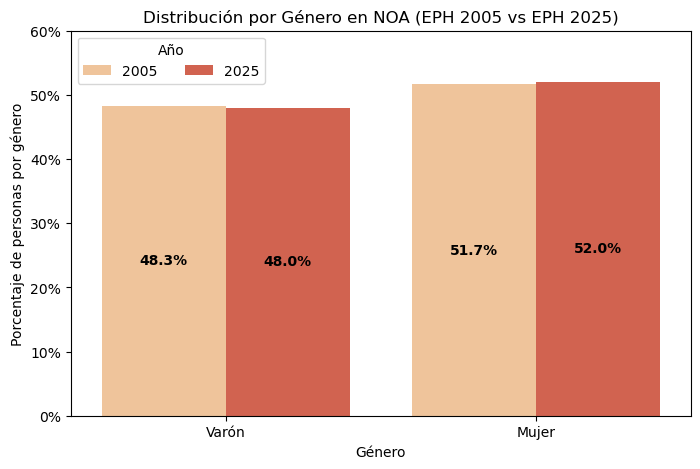

In [15]:
# Calculamos el porcentaje de varones y mujeres por año
porcentaje_genero = eph_105_125.groupby(['df', 'ch04']).size().reset_index(name='cantidad')
porcentaje_genero['porcentaje'] = porcentaje_genero.groupby('df')['cantidad'].transform(lambda x: x / x.sum())
porcentaje_genero["df"] = porcentaje_genero["df"].replace({"T105": "2005", "T125": "2025"})

# Visualizamos los resultados
plt.figure(figsize=(8, 5))
sns.barplot(data=porcentaje_genero, x='ch04', y='porcentaje', hue='df', palette='OrRd')
plt.xticks([0, 1], ['Varón', 'Mujer'])
plt.yticks(np.arange(0, 0.66, 0.1), labels=[f'{int(x*100)}%' for x in np.arange(0, 0.66, 0.1)])
plt.legend(title="Año", loc="upper left", ncol=2)
plt.xlabel('Género')
plt.ylabel('Porcentaje de personas por género')
plt.title('Distribución por Género en NOA (EPH 2005 vs EPH 2025)')

# Agregar etiquetas de porcentaje en cada barra
for i, bar in enumerate(plt.gca().patches):
    height = bar.get_height()
    if height == 0:
        pass
    else:
        # Agregar etiquetas de porcentaje en cada barra, centradas y en negrita, eliminando la última etiqueta extra
        plt.gca().text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.1%}',
            ha='center',
            va='center',
            fontsize=10,
            fontweight='bold'
            )

plt.show()

### 4: Matriz de correlaciones

In [16]:
# Seleccion de variables de interes
corr = pd.DataFrame()

#eph_105_125[['ch04', 'ch06', 'ch07', 'ch08', 'nivel_ed', 'estado', 'cat_inac', 'ipcf']]

# Binarias:
corr["Varon"] = eph_105_125['ch04'].apply(lambda x: 1 if x == 1 else 0)
corr["Mujer"] = eph_105_125['ch04'].apply(lambda x: 1 if x == 2 else 0)

corr["ESTADO_Unido"] = eph_105_125['ch07'].apply(lambda x: 1 if x == 1 else 0) # Unido
corr["ESTADO_Casado"] = eph_105_125['ch07'].apply(lambda x: 1 if x == 2 else 0) # Casado
corr["ESTADO_Divorciado"] = eph_105_125['ch07'].apply(lambda x: 1 if x == 3 else 0) # Divorciado
corr["ESTADO_Viudo"] = eph_105_125['ch07'].apply(lambda x: 1 if x == 4 else 0) # Viudo
corr["ESTADO_Soltero"] = eph_105_125['ch07'].apply(lambda x: 1 if x == 5 else 0) # Soltero

# Agrupamos para la cobertura médica, para simplificar el análisis
corr["Obra social"] = eph_105_125['ch08'].apply(lambda x: 1 if x in [1, 12, 13, 123] else 0) # Obra social
corr["Prepaga"] = eph_105_125['ch08'].apply(lambda x: 1 if x in [2, 12, 23, 123] else 0) # Mutual/prepaga/servicio de emergencia
corr["Planes publicos"] = eph_105_125['ch08'].apply(lambda x: 1 if x in [3, 13, 23, 123] else 0) # Planes y seguros públicos
corr["No tiene"] = eph_105_125['ch08'].apply(lambda x: 1 if x == 4 else 0) # No paga ni le descuentan

corr["Primario Incompleto"] = eph_105_125['nivel_ed'].apply(lambda x: 1 if x in [1] else 0) # Primario incompleto y completo
corr["Primario Completo"] = eph_105_125['nivel_ed'].apply(lambda x: 1 if x in [2] else 0) # Primario completo
corr["Secundario Incompleto"] = eph_105_125['nivel_ed'].apply(lambda x: 1 if x in [3] else 0) # Secundario incompleto
corr["Secundario Completo"] = eph_105_125['nivel_ed'].apply(lambda x: 1 if x in [4] else 0) # Secundario completo
corr["Superior Incompleto"] = eph_105_125['nivel_ed'].apply(lambda x: 1 if x in [5] else 0) # Superior y universitario incompleto
corr["Superior Completo"] = eph_105_125['nivel_ed'].apply(lambda x: 1 if x in [6] else 0) # Superior y universitario completo
corr["Sin Instrucción"] = eph_105_125['nivel_ed'].apply(lambda x: 1 if x == 7 else 0) # Sin instrucción

corr["Ocupado"] = eph_105_125['estado'].apply(lambda x: 1 if x == 1 else 0) # Ocupado
corr["Desocupado"] = eph_105_125['estado'].apply(lambda x: 1 if x == 2 else 0) # Desocupado
corr["Inactivo"] = eph_105_125['estado'].apply(lambda x: 1 if x == 3 else 0) # Inactivo
corr["Menor_de_10"] = eph_105_125['estado'].apply(lambda x: 1 if x == 4 else 0) # Menor de 10 años

corr["Jubilado"] = eph_105_125['cat_inac'].apply(lambda x: 1 if x == 1 else 0) # Jubilado/pensionado
corr["Rentista"] = eph_105_125['cat_inac'].apply(lambda x: 1 if x == 2 else 0) # Rentista
corr["Estudiante"] = eph_105_125['cat_inac'].apply(lambda x: 1 if x == 3 else 0) # Estudiante
corr["Ama_de_casa"] = eph_105_125['cat_inac'].apply(lambda x: 1 if x == 4 else 0) # Ama de casa
corr["Menor_de_6"] = eph_105_125['cat_inac'].apply(lambda x: 1 if x == 5 else 0) # Menor de 6 años
corr["Discapacitado"] = eph_105_125['cat_inac'].apply(lambda x: 1 if x == 6 else 0) # Discapacitado
corr["Otros"] = eph_105_125['cat_inac'].apply(lambda x: 1 if x in [7, 0] else 0) # Otros

corr["Ingreso_per_capita"] = eph_105_125['ipcf'] # Ingreso per cápita
corr["df"] = eph_105_125['df'].replace({"T105": 2005, "T125": 2025}) # Año

C:\Users\marti\AppData\Local\Temp\ipykernel_13256\2096307306.py:44: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  corr["df"] = eph_105_125['df'].replace({"T105": 2005, "T125": 2025}) # Año


<Axes: >

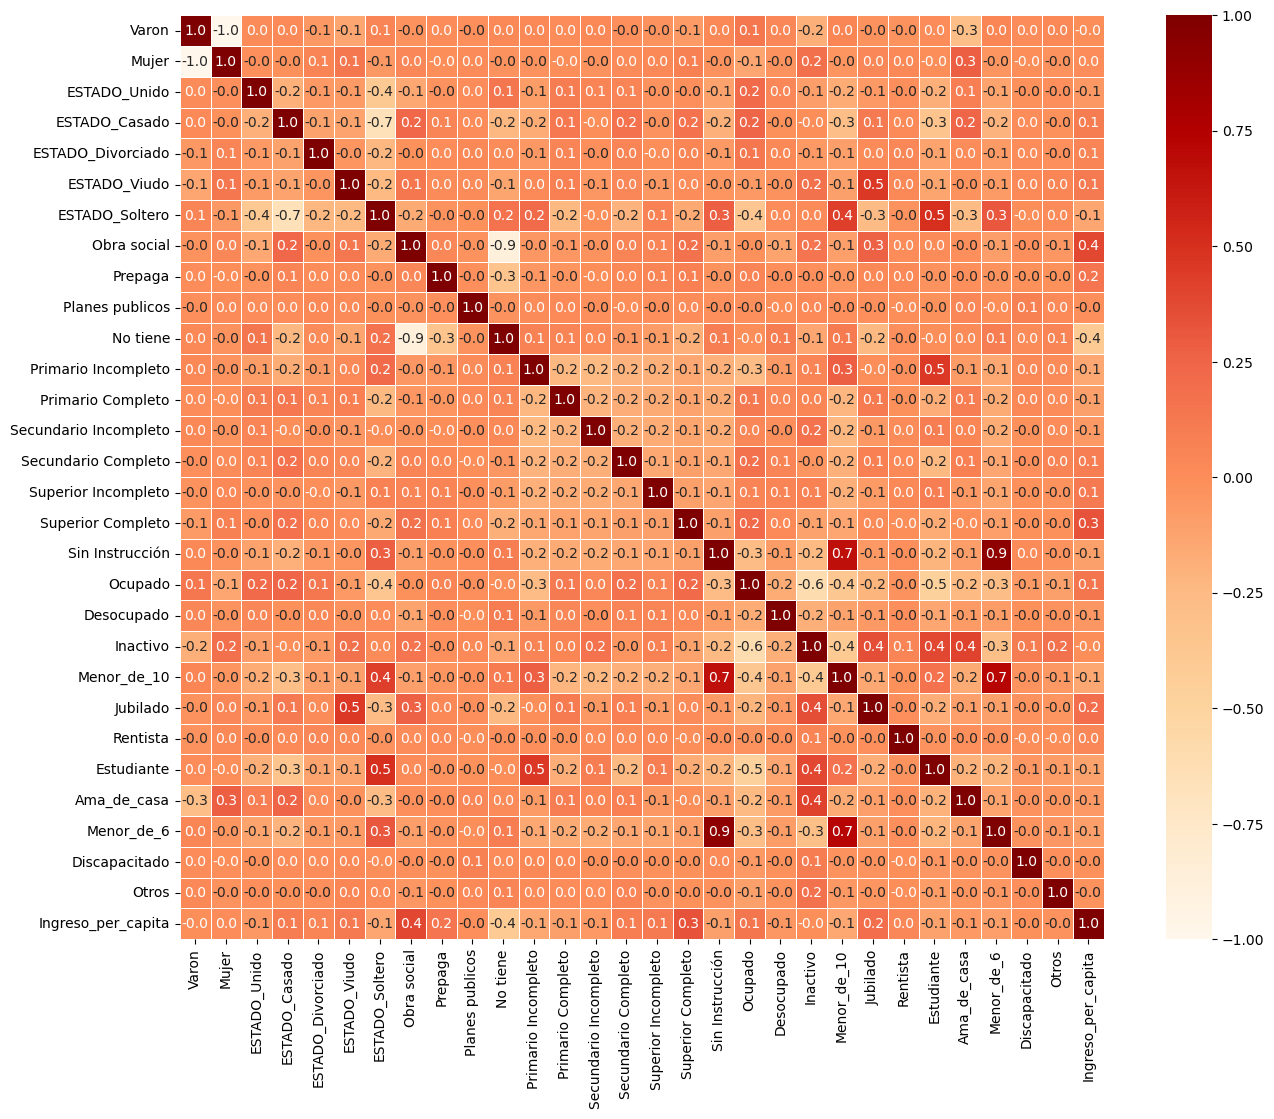

In [17]:
# Correlograma 2005
corr_2005 = corr[corr['df'] == 2005]
corr_2005 = corr_2005.drop(columns=['df'])  # Eliminamos la columna 'df' para el cálculo de correlación
plt.figure(figsize=(16, 12))
sns.heatmap(corr_2005.corr(), annot=True, fmt=".1f", cmap='OrRd', cbar=True, square=True, linewidths=.5)

<Axes: >

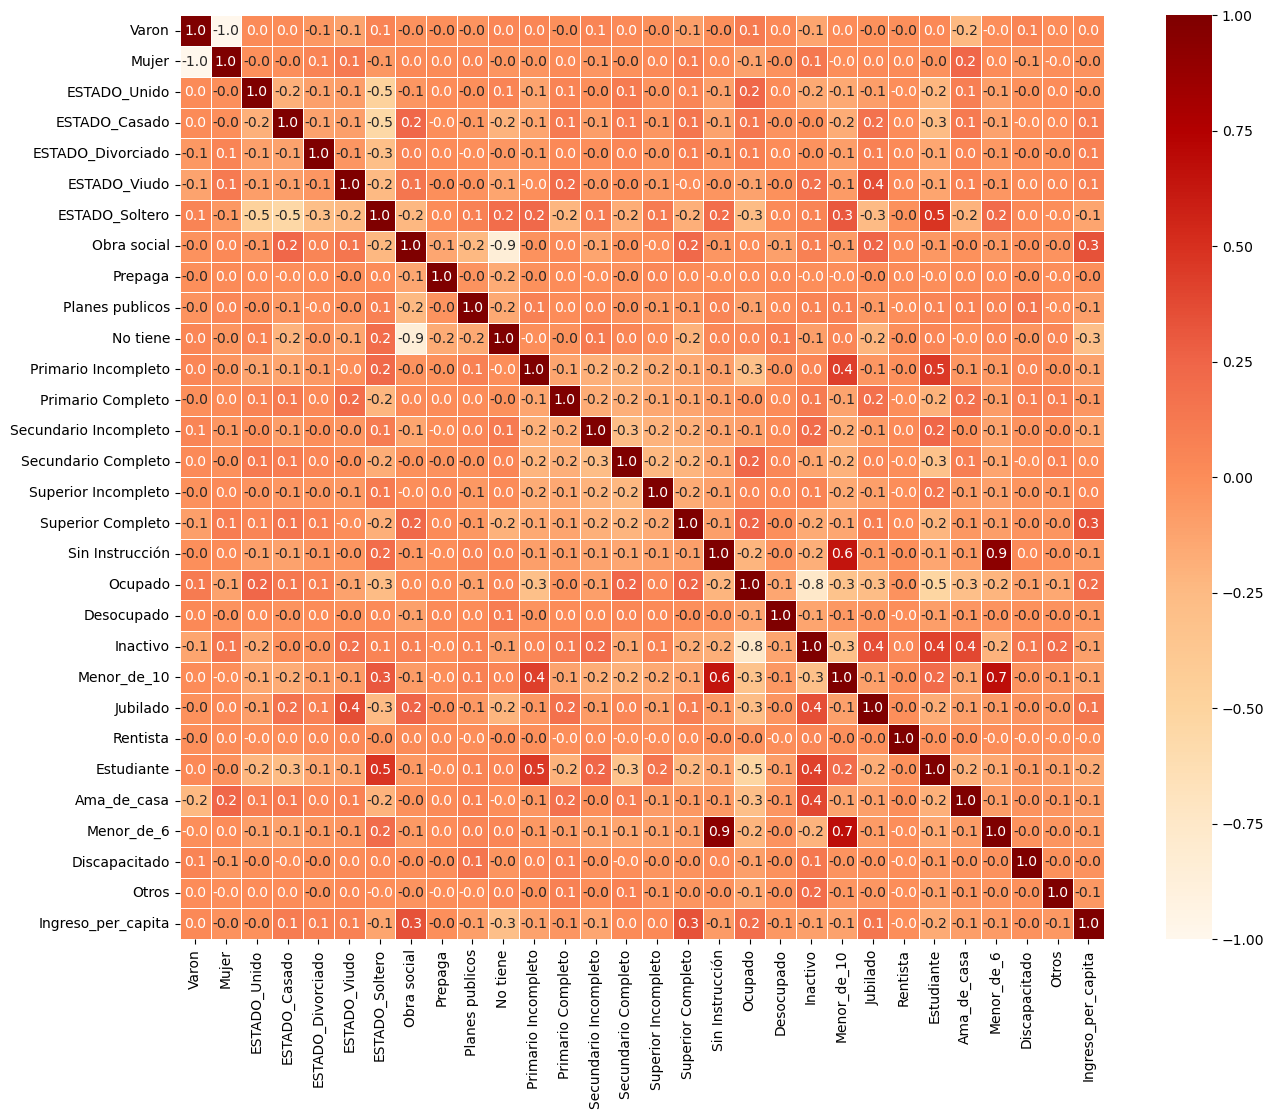

In [18]:
# Correlograma 2025
corr_2025 = corr[corr['df'] == 2025]
corr_2025 = corr_2025.drop(columns=['df'])  # Eliminamos la columna 'df' para el cálculo de correlación
plt.figure(figsize=(16, 12))
sns.heatmap(corr_2025.corr(), annot=True, fmt=".1f", cmap='OrRd', cbar=True, square=True, linewidths=.5)

## PARTE 3

### 5 y 6: No respuesta en ITF y adulto equivalente

Primero crearemos la columna de adulto equivalente y luego realizaremos la partición en base a respuesta de ITF

In [19]:
# Cargamos la tabla adulto
adulto_esquiv = pd.read_excel(path+"GitHub\\Big-Data-UBA--Grupo-2\\base de datos\\tabla_adulto_equiv.xlsx")

adulto_esquiv.sample(5)


,Edad,Mujeres,Varones
20,46 a 60 años,0.76,1.00
0,Menor de 1 año,0.35,0.35
10,10 años,0.70,0.79
1,1año,0.37,0.37
8,8 años,0.68,0.68


In [20]:
# Creamos una función para categorizar las edades
def map_age_to_range(age):
    if age < 1:
        return 'Menor de 1 año'
    elif age == 1:
        return '1 año'
    elif age == 2:
        return '2 años'
    elif age == 3:
        return '3 años'
    elif age == 4:
        return '4 años'
    elif age == 5:
        return '5 años'
    elif age == 6:
        return '6 años'
    elif age == 7:
        return '7 años'
    elif age == 8:
        return '8 años'
    elif age == 9:
        return '9 años'
    elif age == 10:
        return '10 años'
    elif age == 11:
        return '11 años'
    elif age == 12:
        return '12 años'
    elif age == 13:
        return '13 años'
    elif age == 14:
        return '14 años'
    elif age == 15:
        return '15 años'
    elif age == 16:
        return '16 años'
    elif age == 17:
        return '17 años'
    elif 18 <= age <= 29:
        return '18 a 29 años'
    elif 30 <= age <= 45:
        return '30 a 45 años'
    elif 46 <= age <= 60:
        return '46 a 60 años'
    elif 61 <= age <= 75:
        return '61 a 75 años'
    else:
        return 'más de 75 años'

# Agregamos la colummna rango de edad en la base eph
eph_105_125['rango_edad'] = eph_105_125['ch06'].apply(map_age_to_range)

# Renombramos para hacer el merge
adulto_esquiv_renamed = adulto_esquiv.rename(columns={'Edad': 'rango_edad'})

# Unimos las bases
eph_merged = eph_105_125.merge(adulto_esquiv_renamed, on='rango_edad', how='left')

# Creamos columna adulto_esquiv en base a sexo
eph_merged['adulto_esquiv'] = eph_merged.apply(
    lambda row: row['Varones'] if row['ch04'] == 1 else row['Mujeres'] if row['ch04'] == 2 else None,
    axis=1
)

# Eliminamos las variables Mujeres y Varones
eph_merged = eph_merged.drop(columns=['Mujeres', 'Varones'])

# Creamos el concatenado para generar un codigo de hogar
eph_merged['ID_hogar'] = eph_merged['CODUSU'].astype(str) + '-' + eph_merged['nro_hogar'].astype(str)

#Creamos la variable ad_equiv_hogar
eph_merged['ad_equiv_hogar'] = eph_merged.groupby('ID_hogar')['adulto_esquiv'].transform('sum')

# Una vez que hemos creado las variables, creamos las bases del punto 5
respondieron = eph_merged[eph_merged['itf'] > 0]
norespondieron = eph_merged[eph_merged['itf'] == 0]

### 7: Ingreso necesario

In [21]:
# Definir los valores de la Canasta Básica Total por adulto equivalente
cbt_valores = {
    'T105': 205.07,   # Primer trimestre de 2005
    'T125': 365177   # Primer trimestre de 2025
}

# Crear la columna 'ingreso_necesario' multiplicando por el valor correspondiente
respondieron.loc[:,'ingreso_necesario'] = respondieron.apply(
    lambda row: row['ad_equiv_hogar'] * cbt_valores.get(row['df'], 0),
    axis=1
)
respondieron.sample(5)

C:\Users\marti\AppData\Local\Temp\ipykernel_13256\875125945.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  respondieron.loc[:,'ingreso_necesario'] = respondieron.apply(


,CODUSU,nro_hogar,ch03,ch04,ch06,ch07,ch08,nivel_ed,estado,cat_inac,...,ch13,ch14,pp3e_tot,pp3f_tot,df,rango_edad,adulto_esquiv,ID_hogar,ad_equiv_hogar,ingreso_necesario
6115,177702,1.0,3.0,1.0,9.0,5.0,4.0,1.0,4.0,3.0,...,2.0,02,0.0,0.0,T105,9 años,0.69,177702 -1.0,3.84,7.874688e+02
12538,TQRMNORUUHJNLRCDEHJGH00873515,1.0,5.0,2.0,12.0,5.0,3.0,1.0,3.0,3.0,...,2.0,6.0,NaN,NaN,T125,12 años,0.74,TQRMNORUUHJNLRCDEHJGH00873515-1.0,7.46,2.724220e+06
1835,158140,1.0,3.0,1.0,16.0,5.0,4.0,3.0,3.0,3.0,...,2.0,02,0.0,0.0,T105,16 años,1.03,158140 -1.0,4.83,9.904881e+02
8993,267251,1.0,2.0,1.0,31.0,2.0,1.0,5.0,1.0,NaN,...,2.0,02,40.0,0.0,T105,30 a 45 años,1.00,267251 -1.0,3.53,7.238971e+02
12341,TQRMNOQWWHJOLOCDEGPDJ00873694,1.0,3.0,1.0,16.0,5.0,1.0,3.0,3.0,3.0,...,2.0,3.0,NaN,NaN,T125,16 años,1.03,TQRMNOQWWHJOLOCDEGPDJ00873694-1.0,4.33,1.581216e+06


### 8: Columna pobre

In [22]:
# Creamos la variable "pobre"
# Donde 1 es igual a pobre y 0 no pobre
respondieron.loc[:,'pobre'] = (respondieron['itf'] < respondieron['ingreso_necesario']).astype(int)

# Creamos la tabla
tabla_pobreza = (
    respondieron
    .groupby('df', as_index=False)
    .agg(
        pobres=('pobre', lambda x: (x == 1).sum()),
        total=('pobre', 'count')
    )
)
tabla_pobreza['porcentaje'] = (tabla_pobreza['pobres'] / tabla_pobreza['total'] * 100).round(2)
tabla_pobreza

C:\Users\marti\AppData\Local\Temp\ipykernel_13256\3795539360.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  respondieron.loc[:,'pobre'] = (respondieron['itf'] < respondieron['ingreso_necesario']).astype(int)


,df,pobres,total,porcentaje
0,T105,4072,9278,43.89
1,T125,3888,8695,44.72


### 9: Analisis exploratorio de pobre

In [23]:
# Estadísticas descriptivas relevantes de "pobre" por año
desc_pobre = (
    respondieron
    .groupby('df')
    .agg(
        media_pobre=('pobre', 'mean'),
        mediana_pobre=('pobre', 'median'),
        std_pobre=('pobre', 'std'),
        cantidad=('pobre', 'count'),

    )
    .reset_index()
)
desc_pobre['media_pobre'] = (desc_pobre['media_pobre'] * 100).round(2)
desc_pobre

,df,media_pobre,mediana_pobre,std_pobre,cantidad
0,T105,43.89,0.0,0.496278,9278
1,T125,44.72,0.0,0.497228,8695


[<matplotlib.collections.FillBetweenPolyCollection object at 0x000001F09504DBE0>, <matplotlib.collections.FillBetweenPolyCollection object at 0x000001F0995F8A50>, <matplotlib.collections.FillBetweenPolyCollection object at 0x000001F095600550>, <matplotlib.collections.FillBetweenPolyCollection object at 0x000001F095600690>] ['2005', '2005', '2025', '2025']


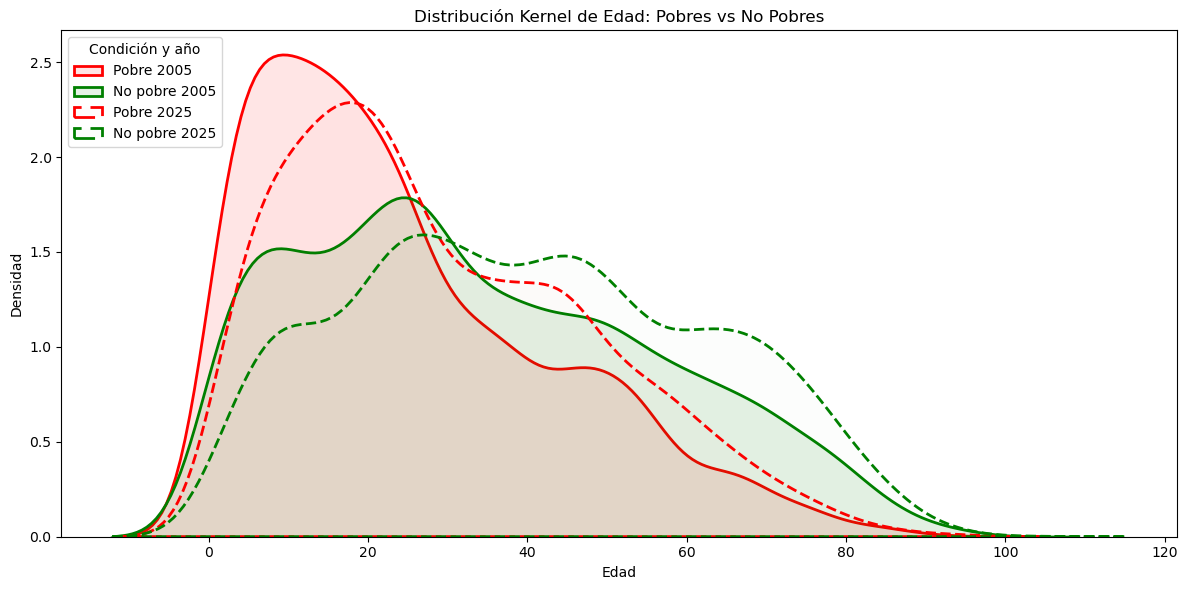

In [24]:
# Gráfico: Distribución kernel de la edad para pobres y no pobres superpuestos
fig, ax = plt.subplots(figsize=(12, 6))
# Distribución kernel de la edad para pobres y no pobres, separados por año
sns.kdeplot(
    data=respondieron[respondieron['df'] == 'T105'],
    x='ch06',
    hue='pobre',
    multiple='layer',
    common_norm=False,
    palette= ['green','red'],
    fill=True,
    alpha=0.1,
    linewidth=2,
    label='2005',
    ax=ax
)
sns.kdeplot(
    data=respondieron[respondieron['df'] == 'T125'],
    x='ch06',
    hue='pobre',
    multiple='layer',
    common_norm=False,
    palette=['green', 'red'],
    fill=True,
    alpha=0.01,
    linewidth=2,
    label='2025',
    linestyle='--',
    ax=ax
)

# Actualizamos la leyenda manualmente para mostrar todas las combinaciones
handles, labels = plt.gca().get_legend_handles_labels()
print(handles, labels)
custom_labels = ['Pobre 2005', 'No pobre 2005', 'Pobre 2025', 'No pobre 2025']
plt.legend(handles, custom_labels, title='Condición y año', loc='upper right')
plt.gca().legend(handles=plt.gca().get_legend_handles_labels()[0], labels=custom_labels, title='Condición y año', loc='upper left')

plt.yticks(np.arange(0, 0.026, 0.005), labels=[f'{x*100:.1f}' for x in np.arange(0, 0.026, 0.005)])
plt.xlabel('Edad')
plt.ylabel('Densidad')
plt.title('Distribución Kernel de Edad: Pobres vs No Pobres')
plt.tight_layout()
plt.show()

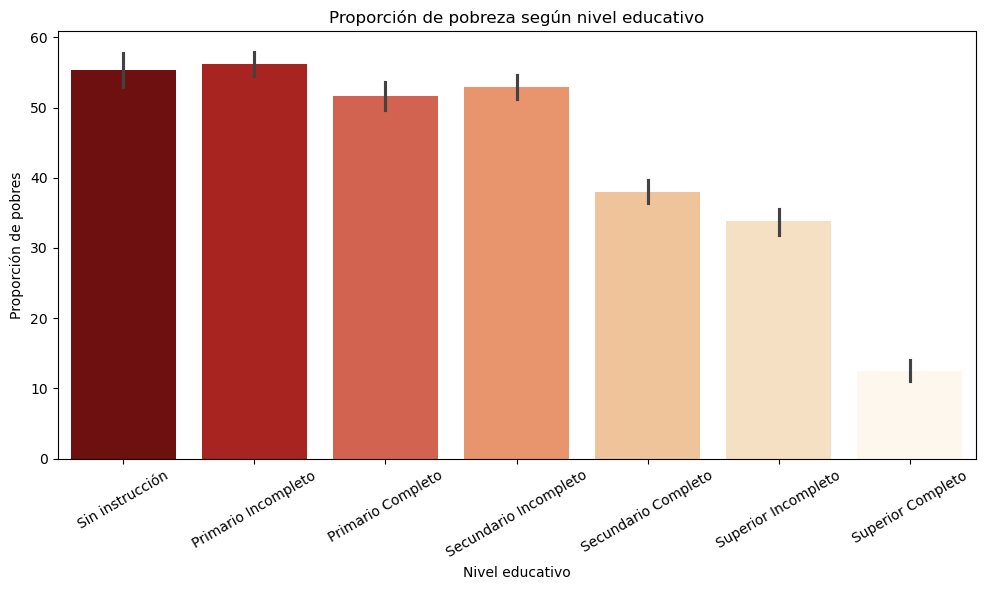

In [25]:
barras = respondieron.copy()
barras.loc[:,"nivel_ed"] = barras["nivel_ed"].replace(7,0)


# Gráfico de barras: proporción de pobres por nivel educativo
plt.figure(figsize=(10, 6))


sns.barplot(
    data=barras,
    x='nivel_ed',
    hue = 'nivel_ed',
    legend = False,
    y='pobre',
    estimator=np.mean,
    palette='OrRd_r'
)

plt.xlabel('Nivel educativo')
plt.ylabel('Proporción de pobres')
plt.title('Proporción de pobreza según nivel educativo')
plt.xticks(
    ticks=[0, 1, 2, 3, 4, 5, 6],
    labels=[
        'Sin instrucción', 'Primario Incompleto', 'Primario Completo',
        'Secundario Incompleto', 'Secundario Completo',
        'Superior Incompleto', 'Superior Completo'
    ],
    rotation=30
)
plt.yticks(np.arange(0, 0.61, 0.1), labels=[f'{x*100:.0f}' for x in np.arange(0, 0.61, 0.1)])


plt.tight_layout()
plt.show()

# TP2

## PARTE 1

### 1. Creación de la variable edad^2 e histograma

In [26]:
# Creamos la variable edad al cuadrado
eph_105_125['edad2'] = eph_105_125['ch06'] ** 2   # CH06 = edad según diccionario EPH

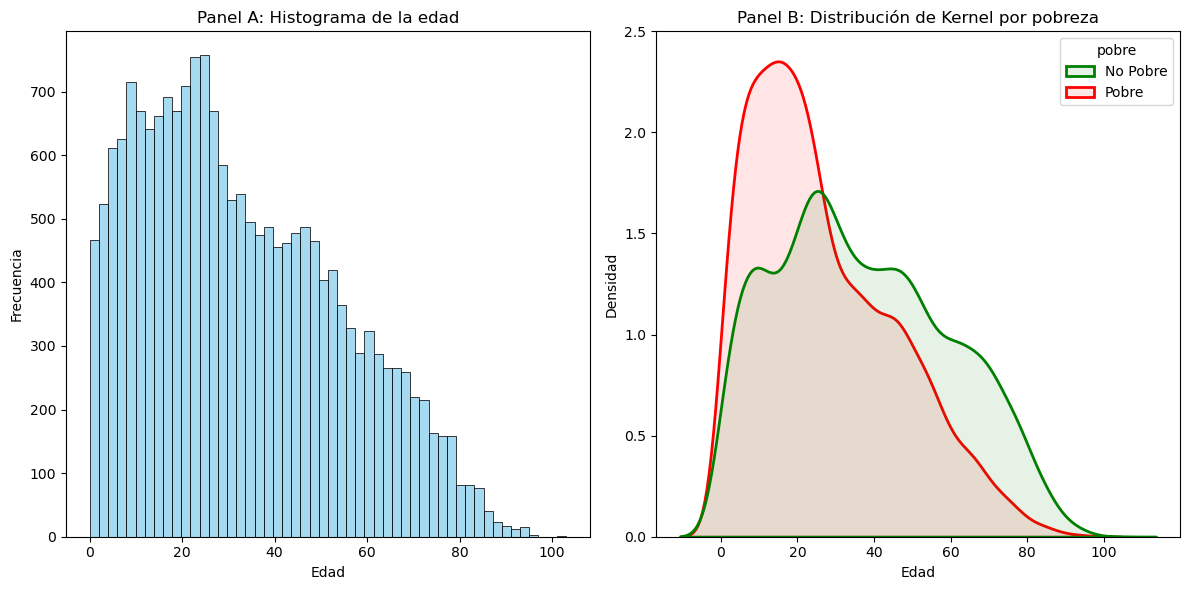

In [27]:
# Gráfico: Distribución kernel de la edad para pobres y no pobres superpuestos
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
# Panel A: Histograma de la edad
sns.histplot(eph_105_125['ch06'],
             binwidth=2,
             kde=False, 
             color='skyblue',
             ax = ax[0])
plt.subplot(1,2,1)
plt.title("Panel A: Histograma de la edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

# Panel B: Kernel density para pobres y no pobres
sns.kdeplot(data=respondieron, 
            x='ch06', 
            hue='pobre', 
            common_norm=False, 
            palette= [ 'green', 'red',],
            fill=True, 
            alpha=0.1, 
            linewidth=2,
            ax = ax[1])

# Corregimos las etiquetas de la leyenda
new_labels =  ['No Pobre', "Pobre"]
for t, l in zip(ax[1].legend_.texts, new_labels):
    t.set_text(l)

plt.subplot(1,2,2)
plt.title("Panel B: Distribución de Kernel por pobreza")
plt.xlabel("Edad")
plt.ylabel("Densidad")
plt.yticks(np.arange(0, 0.026, 0.005), labels=[f'{x*100:.1f}' for x in np.arange(0, 0.026, 0.005)])

plt.tight_layout()
plt.show()

### 2. Años de educación

In [28]:
# Convertirmos la variable object en numerica
eph_105_125['ch14'] = pd.to_numeric(eph_105_125['ch14'], errors='coerce')

# Mapas
mapa_niveles = {
    1: 0, 2: 6, 3: 9, 4: 12, 5: 12, 6: 14, 7: 17, 8: 20, 9: np.nan
}
años_previos = {
    1: 0, 2: 0, 3: 6, 4: 9, 5: 9, 6: 12, 7: 14, 8: 17, 9: 0
}

# Crear variable educ
eph_105_125['educ'] = np.where(
    eph_105_125['ch12'].isna(), 
    0,
    np.where(
        eph_105_125['ch13'] == 1,  # Si finalizó el nivel
        eph_105_125['ch12'].map(mapa_niveles),
        eph_105_125['ch12'].map(años_previos) + eph_105_125['ch14'].fillna(0)
    )
)

eph_105_125['educ'] = eph_105_125['educ'].fillna(0)

In [29]:
desc_educ = eph_105_125['educ'].describe(percentiles=[0.5])
print(desc_educ)

count    19090.000000
mean        10.321530
std          8.685464
min          0.000000
50%         12.000000
max        113.000000
Name: educ, dtype: float64


### 3. Actualización de ITF

In [30]:
# Factor de conversión 2005 → 2025
factor_conversion = 969.61 # Equivalencia de un peso en mazo de 2005 a pesos de marzo de 2025

# Creamos variable ingreso_total_familiar homogeneizada en miles de pesos de 2025
eph_105_125['ingreso_total_familiar'] = eph_105_125.apply(
    lambda row: row['itf'] * factor_conversion /1000 if row['df'] == 'T105' else row['itf']/1000,
    axis=1
)


In [31]:
# Línea de pobreza (2025, pesos corrientes)
linea_pobreza = 365177/1000  # En miles de pesos de 2025

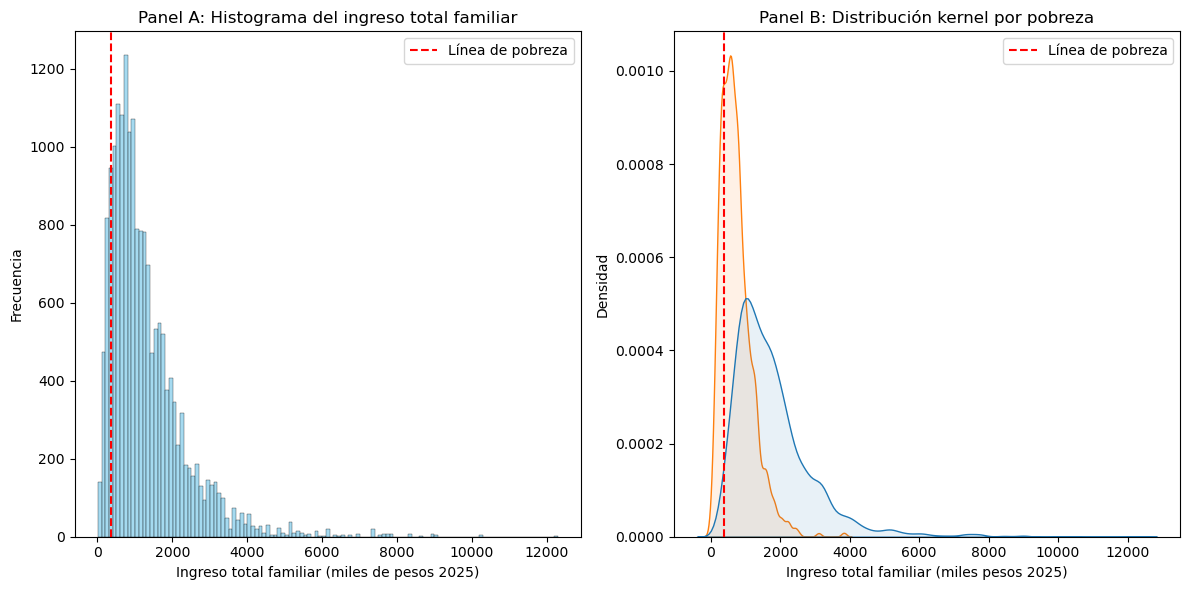

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Panel A: Histograma ingreso_total_familiar
plt.subplot(1,2,1)
sns.histplot(eph_105_125['ingreso_total_familiar'], 
             binwidth=100, 
             kde=False, 
             color='skyblue')
plt.axvline(linea_pobreza, color='red', linestyle='--', label='Línea de pobreza')
plt.title("Panel A: Histograma del ingreso total familiar")
plt.xlabel("Ingreso total familiar (miles de pesos 2025)")
plt.ylabel("Frecuencia")
plt.legend()

# Panel B: Distribución kernel pobres vs no pobres
plt.subplot(1,2,2)
sns.kdeplot(data=respondieron, 
            x=eph_105_125['ingreso_total_familiar'], 
            hue='pobre', 
            fill=True, 
            common_norm=False, 
            alpha=0.1)
plt.axvline(linea_pobreza, color='red', linestyle='--', label='Línea de pobreza')
plt.title("Panel B: Distribución kernel por pobreza")
plt.xlabel("Ingreso total familiar (miles pesos 2025)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()


### 4. Variable de horas trabajadas

In [33]:
# Creamos variable horastrab solo para jefes de hogar
eph_105_125['horastrab'] = eph_105_125[['pp3e_tot', 'pp3f_tot']].sum(axis=1)

# Filtramos jefes de hogar
jefes = eph_105_125[eph_105_125['ch03'] == 1]


In [34]:
# Descriptivas de horastrab
desc_horas = jefes['horastrab'].describe(percentiles=[0.5])
print(desc_horas)

count    5385.000000
mean       23.561560
std        24.765294
min         0.000000
50%        20.000000
max       126.000000
Name: horastrab, dtype: float64


### 5. Tamaño con variables unificadas

In [35]:
# Añadimos la variable pobre del df respondieron al df eph_105_125
eph_105_125 = eph_105_125.merge(
    respondieron[['CODUSU', 'nro_hogar', 'pobre']],
    on=['CODUSU', 'nro_hogar'],
    how='left'
)

# Añadimos la variable miembros del hogar del df respondieron al df eph_105_125
eph_105_125 = eph_105_125.merge(
    HOG_105_125[['CODUSU', 'nro_hogar', 'IX_Tot']],
    on=['CODUSU', 'nro_hogar'],
    how='left'
)

In [36]:
# Cant obs:
lenT105 = len(eph_105_125[eph_105_125['df'] == 'T105'])
lenT125 = len(eph_105_125[eph_105_125['df'] == 'T125'])

# Cant obs NAs en la variable Pobre:
lenpobreNAsT105 = eph_105_125[eph_105_125['df'] == 'T105']['pobre'].isna().sum()
lenpobreNAsT125 = eph_105_125[eph_105_125['df'] == 'T125']['pobre'].isna().sum()

# Cant obs de la variable Pobre:
len_pobre_T105 = len(eph_105_125[(eph_105_125['pobre'] == 1) & (eph_105_125['df'] == 'T105')])
len_pobre_T125 = len(eph_105_125[(eph_105_125['pobre'] == 1) & (eph_105_125['df'] == 'T125')])

# Cantidad de variables limpias y homogeneizada
varsT105 = ((eph_105_125[eph_105_125['df'] == 'T105'] != 0) & (~eph_105_125[eph_105_125['df'] == 'T105'].isna())).any(axis=0).sum()
varsT125 = ((eph_105_125[eph_105_125['df'] == 'T125'] != 0) & (~eph_105_125[eph_105_125['df'] == 'T125'].isna())).any(axis=0).sum()

# Mostramos el resultado
print(f"Cantidad de observaciones para el año 2005 es: {lenT105}")
print(f"Cantidad de observaciones para el año 2025 es: {lenT125}")
print(f"Total: {lenT105 + lenT125}")
print(f"Cantidad de NAs en la var pobre para el año 2005 es: {lenpobreNAsT105}")
print(f"Cantidad de NAs en la var pobre para el año 2025 es: {lenpobreNAsT125}")
print(f"Total: {lenpobreNAsT105 + lenpobreNAsT125}")
print(f"Cantidad de pobres para el año 2005 es: {len_pobre_T105}")
print(f"Cantidad de pobres para el año 2025 es: {len_pobre_T125}")
print(f"Total: {len_pobre_T105 + len_pobre_T125}")
print(f"Cantidad de no pobre para el año 2005 es: {lenT105-len_pobre_T105}")
print(f"Cantidad de no pobre para el año 2025 es: {lenT125-len_pobre_T125}")
print(f"Total: {lenT105 + lenT125-len_pobre_T105-len_pobre_T125}")
print(f"Cantidad de var limpias y homogeneizadas año 2005 es: {varsT105}")
print(f"Cantidad de var limpias y homogeneizadas año 2005 es: {varsT125}")
print(f"Total: {varsT105 + varsT125}")

Cantidad de observaciones para el año 2005 es: 49156
Cantidad de observaciones para el año 2025 es: 37242
Total: 86398
Cantidad de NAs en la var pobre para el año 2005 es: 70
Cantidad de NAs en la var pobre para el año 2025 es: 1047
Total: 1117
Cantidad de pobres para el año 2005 es: 25506
Cantidad de pobres para el año 2025 es: 18856
Total: 44362
Cantidad de no pobre para el año 2005 es: 23650
Cantidad de no pobre para el año 2025 es: 18386
Total: 42036
Cantidad de var limpias y homogeneizadas año 2005 es: 32
Cantidad de var limpias y homogeneizadas año 2005 es: 32
Total: 64


## Parte II: Métodos No Supervisados

In [37]:
#Instalamos los paquetes necesarios
# !pip install statsmodels
# !pip install scikit-learn
# !pip install ISLP

In [38]:
# Cargamos paquetes
import ISLP
from ISLP import load_data
from statsmodels.datasets import get_rdataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

### 1. Matriz de correlaciones

In [39]:
#Seleccionamos las variables
select_var_pca = ['ch06','edad2','educ','ingreso_total_familiar','horastrab','IX_Tot']
#Creamos la base a trabajar
eph_105_125_pca = eph_105_125[select_var_pca]
eph_105_125_pca_abs = eph_105_125_pca.copy()

# Creamos el imputador basado en media para no perder valores
imputer = SimpleImputer(strategy='mean')

# Imputamos valores NA del IX_Tot
eph_105_125_pca = eph_105_125_pca.copy()

eph_105_125_pca[['IX_Tot']] = imputer.fit_transform(
    eph_105_125_pca[['IX_Tot']]
)

# Imputamos valores NA del educ
eph_105_125_pca[['educ']] = imputer.fit_transform(
    eph_105_125_pca[['educ']]
)

<Axes: >

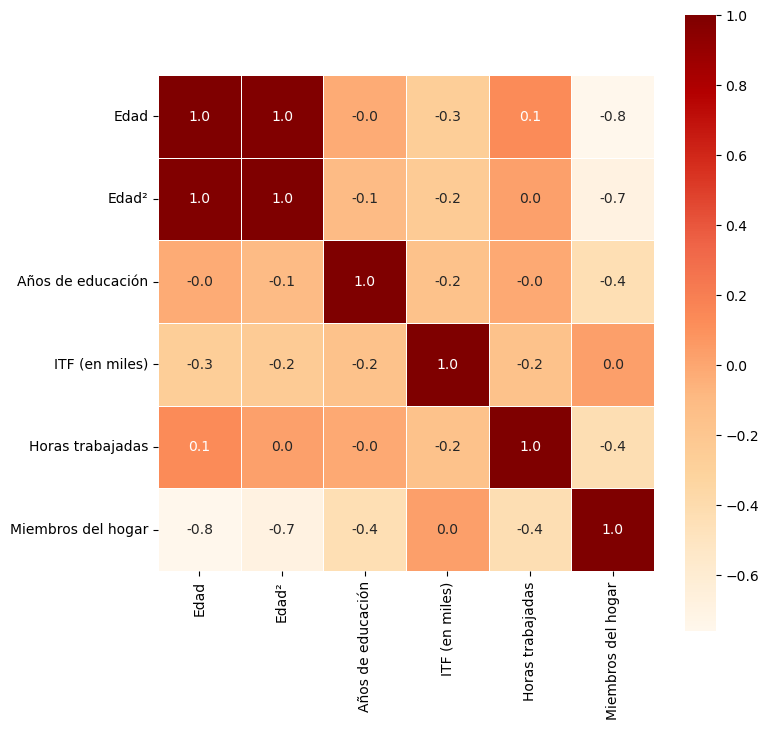

In [40]:
# Correlograma
corr_pca = eph_105_125_pca.corr()
corr_pca.columns = ['Edad', 'Edad²', 'Años de educación', 'ITF (en miles)', 'Horas trabajadas', 'Miembros del hogar']

plt.figure(figsize=(8, 8))
sns.heatmap(corr_pca.corr(), annot=True, fmt=".1f", cmap='OrRd', cbar=True, square=True, linewidths=.5)

### A.2. PCA con ingreso 

In [41]:
# Inicializamos el transformador
scaler = StandardScaler(with_std=True, with_mean=True) 
# Aplicamos fit_transform al DataFrame
eph_105_125_pca_transformed = pd.DataFrame(scaler.fit_transform(eph_105_125_pca), columns=eph_105_125_pca.columns)

In [42]:
# Revisamos que se tenga media 0 y desviación estandar de 1 para confirmar la normalización de las variables
eph_105_125_pca_transformed.describe().round(2)

,ch06,edad2,educ,ingreso_total_familiar,horastrab,IX_Tot
count,86398.00,86398.00,86398.00,85281.00,86398.00,86398.00
mean,0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.42,-0.82,-1.12,-1.25,-0.62,-1.74
25%,-0.84,-0.73,-0.43,-0.66,-0.62,-0.69
50%,-0.20,-0.42,0.14,-0.27,-0.62,-0.34
75%,0.73,0.43,0.26,0.36,0.57,0.37
max,3.61,6.06,11.84,9.96,5.38,4.23


In [43]:
# Aplicamos el PCA y calculamos los scores
pca = PCA()
arrests_pca = pca.fit_transform(eph_105_125_pca_transformed)

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

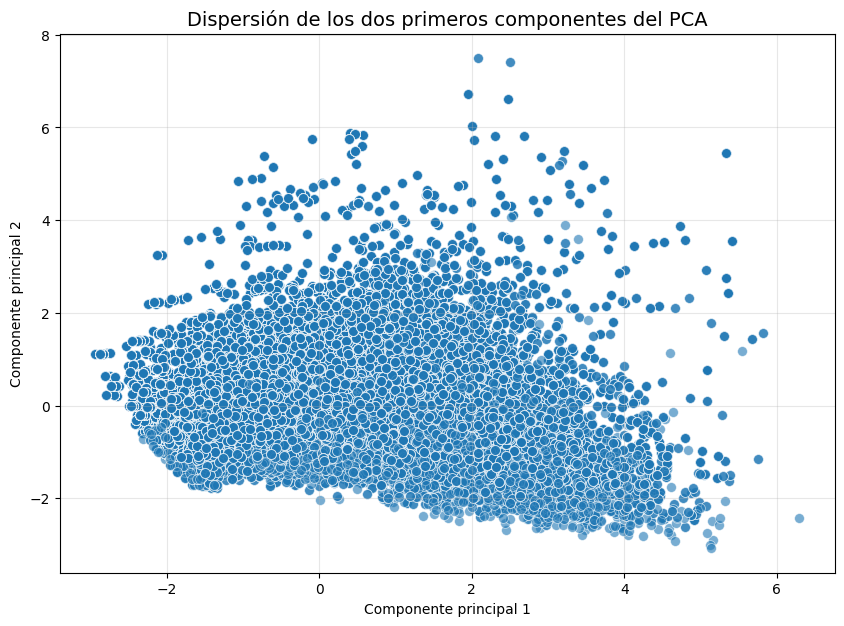

In [ ]:
# Creamos un DataFrame con los dos primeros componentes
pca_df = pd.DataFrame(
    data=arrests_pca[:, :2],
    columns=['Componente 1', 'Componente 2']
)

# Gráfico de dispersión
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x='Componente 1',
    y='Componente 2',
    alpha=0.6,
    s=50
)
plt.title('Dispersión de los dos primeros componentes del PCA', fontsize=14)
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.grid(True, alpha=0.3)
plt.show()

### A.3. Pesos

In [ ]:
# Loadings vectors (ponderadores, en ecuacion 4 son los phi.

loadings = pca.components_ # cada fila corresponde a un CP y cada columna, a una variable
print("Loadings:\n", pca.components_)
print("Loadings del CP1:\n",pca.components_[0]) 
pca.components_[0,0] #loadings del CP1 variable 1, phi(1,1) en ecuacion 4
print("Loadings del CP2:\n",pca.components_[1]) 

Loadings:
 [[ 0.64819851  0.61861317  0.19476743  0.11483146  0.2653684  -0.2749826 ]
 [-0.0714848  -0.15828465  0.33551356  0.72973011  0.40108036  0.40483954]
 [-0.1956671  -0.31041667  0.66978521 -0.25434896  0.2755132  -0.52549285]
 [-0.04546182 -0.11063797 -0.50778809 -0.23371006  0.8202127  -0.02178214]
 [ 0.1459162   0.10128396  0.37206826 -0.57878119  0.10565072  0.69560441]
 [ 0.7162993  -0.68804506 -0.06782732  0.00250172 -0.09431696  0.00261248]]
Loadings del CP1:
 [ 0.64819851  0.61861317  0.19476743  0.11483146  0.2653684  -0.2749826 ]
Loadings del CP2:
 [-0.0714848  -0.15828465  0.33551356  0.72973011  0.40108036  0.40483954]


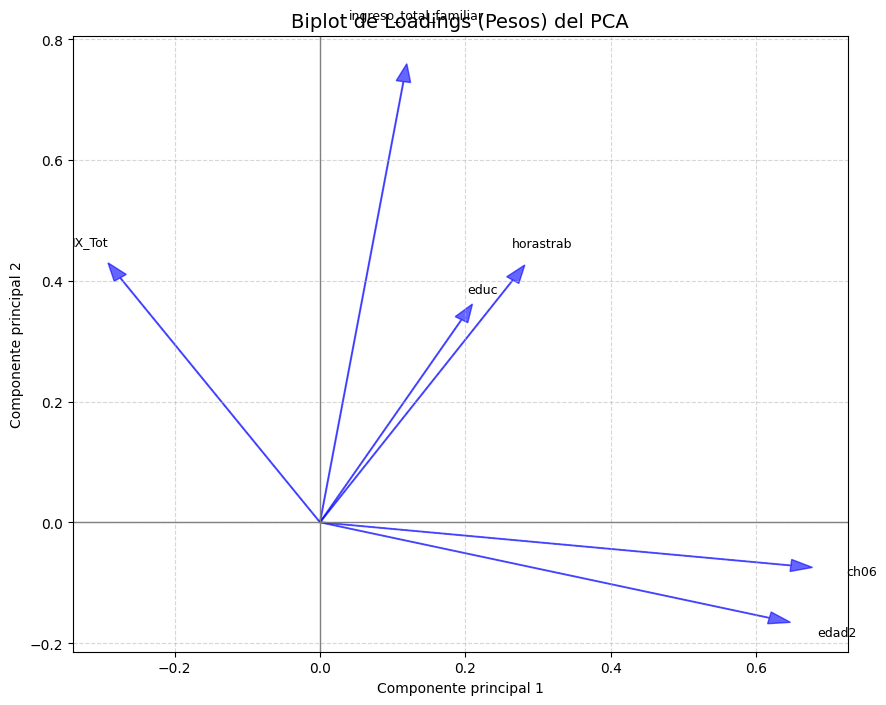

In [ ]:
# Obtenemos los loadings (ponderadores)
loadings = pd.DataFrame(
    pca.components_.T[:, :2],  # solo los dos primeros componentes
    columns=['Componente 1', 'Componente 2'],
    index=eph_105_125_pca_transformed.columns
)
# Creamos el gráfico de las flechas
plt.figure(figsize=(10, 8))
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)

# Dibujamos una flecha por cada variable
for i in loadings.index:
    plt.arrow(0, 0,
              loadings.loc[i, 'Componente 1'],
              loadings.loc[i, 'Componente 2'],
              color='blue', alpha=0.6,
              head_width=0.02)
    plt.text(loadings.loc[i, 'Componente 1'] * 1.15,
             loadings.loc[i, 'Componente 2'] * 1.15,
             i, color='black', ha='center', va='center', fontsize=9)

plt.title('Biplot de Loadings (Pesos) del PCA', fontsize=14)
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### A.4. Varianza explicada

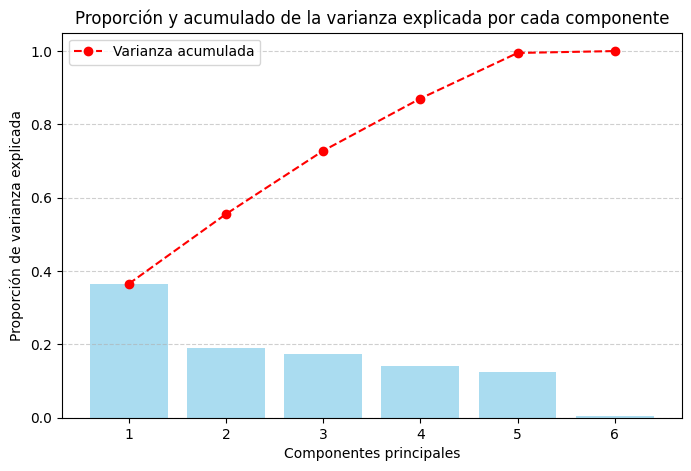

In [ ]:
# Proporción de la varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.7, color='skyblue')
plt.plot(range(1, len(varianza_explicada) + 1),
         np.cumsum(varianza_explicada),
         marker='o', color='red', linestyle='--', label='Varianza acumulada')

plt.xlabel('Componentes principales')
plt.ylabel('Proporción de varianza explicada')
plt.title('Proporción y acumulado de la varianza explicada por cada componente')
plt.xticks(range(1, len(varianza_explicada) + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


### B.5 Cluster k-medias

In [ ]:
# Importamos las librerias
from sklearn.cluster import KMeans, AgglomerativeClustering

In [ ]:
# Aplicamos K-means con diferentes números de clusters
kmeans2 = KMeans(n_clusters=2, random_state=10, init="random", n_init=20).fit(eph_105_125_pca_abs)
kmeans4 = KMeans(n_clusters=4, random_state=10, init="random", n_init=20).fit(eph_105_125_pca_abs)
kmeans10 = KMeans(n_clusters=10, random_state=10, init="random", n_init=20).fit(eph_105_125_pca_abs)

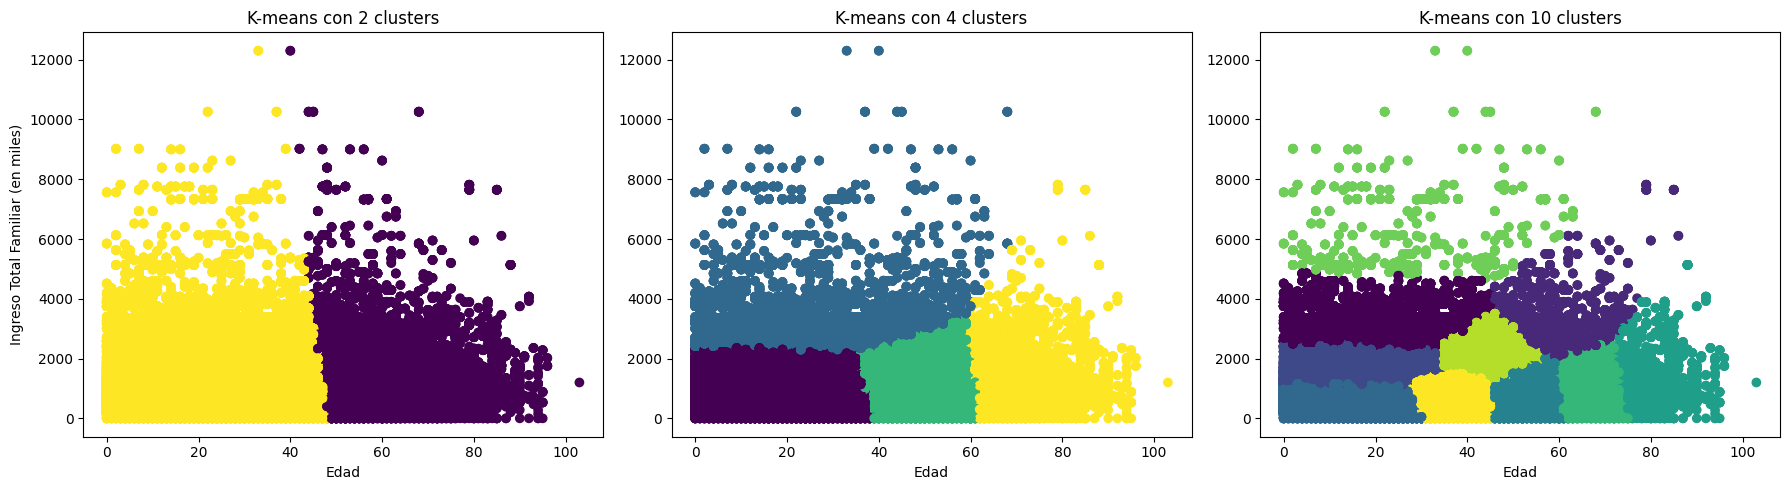

In [ ]:
# Creamos los gráficos con las variables edad e ingreso_total_familiar
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.scatter(eph_105_125['ch06'], eph_105_125['ingreso_total_familiar'], c=kmeans2.labels_, cmap='viridis')
plt.title('K-means con 2 clusters')
plt.xlabel('Edad')
plt.ylabel('Ingreso Total Familiar (en miles)')


# Segundo gráfico
plt.subplot(1, 3, 2)
plt.scatter(eph_105_125['ch06'], eph_105_125['ingreso_total_familiar'], c=kmeans4.labels_, cmap='viridis')
plt.title('K-means con 4 clusters')
plt.xlabel('Edad')


# Tercer gráfico
plt.subplot(1, 3, 3)
plt.scatter(eph_105_125['ch06'], eph_105_125['ingreso_total_familiar'], c=kmeans10.labels_, cmap='viridis')
plt.title('K-means con 10 clusters')
plt.xlabel('Edad')

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

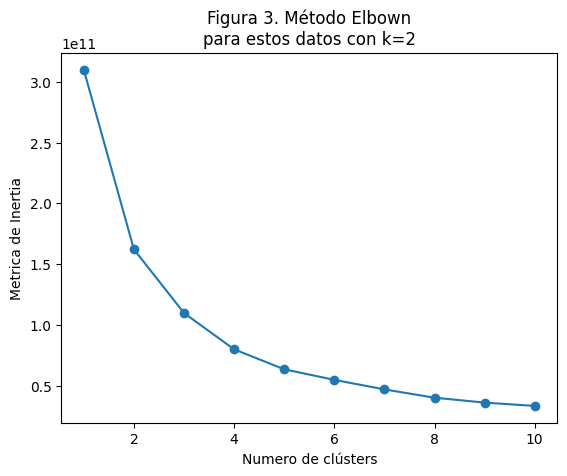

In [ ]:
# Medidas de disimilitud intra-cluster
n_cluster_range = range(1,11)

# Objeto para guardad los valores de inertia
inertia_values = []

# Loop para probar distintos valores de cluser
for n_clusters in n_cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=10)
    kmeans.fit(eph_105_125_pca_abs)
    inertia_values.append(kmeans.inertia_)
 
# Ahora graficamos como cambia inertia con los distintos clusters
plt.plot(n_cluster_range,inertia_values, marker='o')
plt.xlabel('Numero de clústers')
plt.ylabel('Metrica de Inertia')
plt.title('Figura 3. Método Elbown\npara estos datos con k=2')
plt.show

### B.6 Cluster jerárquico

In [ ]:
# Importamos las librerias
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [ ]:
# Retomamos los datos estandarizados usados en el PCA y le aplicamos linkage jerárquico

# Dado el tamaño del dataframe, se vuelve computacionalmente muy dificil de hacer. 
# Tomamos un sample mas pequeño para realizarlo
eph_link = eph_105_125_pca_transformed.sample(n=5000, random_state=20102025)
linkage_data = linkage(eph_link, metric='euclidean')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14320\3907892420.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


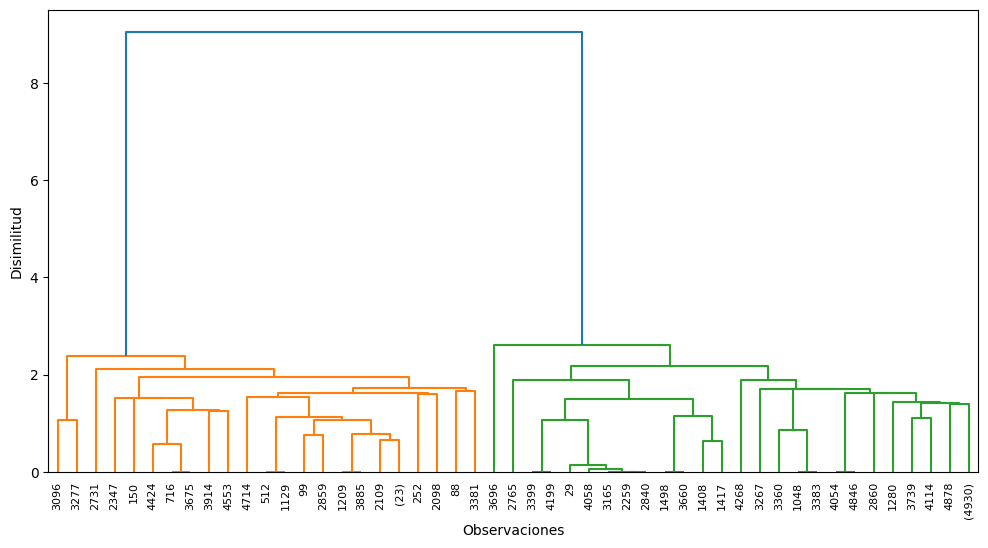

In [ ]:
# Graficamos el dendograma
fig, ax = plt.subplots(figsize=(12,6))
dendrogram(linkage_data,truncate_mode="level", p=10)
ax.set_xlabel("Observaciones")
ax.set_ylabel("Disimilitud")
fig.show()

TP 3

PARTE A

Consigna 1

In [44]:
respondieron.columns.tolist()


['CODUSU',
 'nro_hogar',
 'ch03',
 'ch04',
 'ch06',
 'ch07',
 'ch08',
 'nivel_ed',
 'estado',
 'cat_inac',
 'ipcf',
 'cat_ocup',
 'pp03c',
 'pp03i',
 'pp10a',
 'p21',
 'tot_p12',
 't_vi',
 'itf',
 'ch12',
 'ch13',
 'ch14',
 'pp3e_tot',
 'pp3f_tot',
 'df',
 'rango_edad',
 'adulto_esquiv',
 'ID_hogar',
 'ad_equiv_hogar',
 'ingreso_necesario',
 'pobre']

In [45]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# ======================
# SELECCIÓN DE VARIABLES (sin ingresos)
# ======================
variables_X = [
    'ch06', 'nivel_ed', 'estado', 'cat_inac', 'cat_ocup',
    'pp10a', 'p21', 't_vi', 'adulto_esquiv', 'ad_equiv_hogar'
]

X = respondieron[variables_X].copy()
y = respondieron['pobre'].astype(int)

# Agregar intercepto (columna de unos)
X['intercept'] = 1

# ======================
# TRAIN/TEST SPLIT
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=444
)

# ======================
# TABLA DE MEDIAS ENTRE TRAIN Y TEST
# ======================
tabla_medias = pd.DataFrame({
    'Media_Train': X_train.mean(),
    'Media_Test': X_test.mean(),
    'Diferencia': X_train.mean() - X_test.mean()
})

print(tabla_medias)


                  Media_Train     Media_Test    Diferencia
ch06                32.337175      32.793398     -0.456223
nivel_ed             3.615611       3.629636     -0.014026
estado               2.321431       2.301187      0.020244
cat_inac             3.413437       3.402459      0.010978
cat_ocup             2.744574       2.758738     -0.014164
pp10a                2.917391       2.950549     -0.033158
p21             309272.375026  314760.172283  -5487.797257
t_vi            258066.373106  272706.535135 -14640.162029
adulto_esquiv        0.810421       0.809940      0.000481
ad_equiv_hogar       3.749800       3.777778     -0.027978
intercept            1.000000       1.000000      0.000000


Consigna 2

In [46]:
# ======================
# Separar respondieron
# ======================
respondieron_2005 = respondieron[respondieron['df'] == 'T105'].copy()
respondieron_2025 = respondieron[respondieron['df'] == 'T125'].copy()

# ======================
# Separar norespondieron
# ======================
norespondieron_2005 = norespondieron[norespondieron['df'] == 'T105'].copy()
norespondieron_2025 = norespondieron[norespondieron['df'] == 'T125'].copy()


PARTE B. Modelo de Regresion Logística

Consigna 3

In [47]:
X_train_2025.isna().sum()


NameError: name 'X_train_2025' is not defined

In [48]:
y_train_2025.isna().sum()


NameError: name 'y_train_2025' is not defined

In [49]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

resp_2025 = respondieron_2025.copy()

variables_X = [
    'ch06', 'nivel_ed', 'estado', 'cat_inac', 'cat_ocup',
    'pp10a', 'p21', 't_vi', 'adulto_esquiv', 'ad_equiv_hogar'
]

# 1. Convertir a numérico + imputar medianas
for col in variables_X:
    resp_2025[col] = pd.to_numeric(resp_2025[col], errors='coerce')
    resp_2025[col] = resp_2025[col].fillna(resp_2025[col].median())

# 2. Definir X e y
X_2025 = resp_2025[variables_X].copy()
y_2025 = resp_2025['pobre'].astype(int)

# 3. Intercepto
X_2025 = sm.add_constant(X_2025)

# 4. Train-test
X_train_2025, X_test_2025, y_train_2025, y_test_2025 = train_test_split(
    X_2025, y_2025, test_size=0.30, random_state=444
)

# 5. Logit
logit_model = sm.Logit(y_train_2025, X_train_2025)
resultado = logit_model.fit()

print(resultado.summary())


Optimization terminated successfully.
         Current function value: 0.553029
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  pobre   No. Observations:                 6086
Model:                          Logit   Df Residuals:                     6075
Method:                           MLE   Df Model:                           10
Date:                Sat, 15 Nov 2025   Pseudo R-squ.:                  0.1952
Time:                        15:27:07   Log-Likelihood:                -3365.7
converged:                       True   LL-Null:                       -4182.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0455      0.461     -0.099      0.921      -0.950       0.858
ch06             

Consigna 4

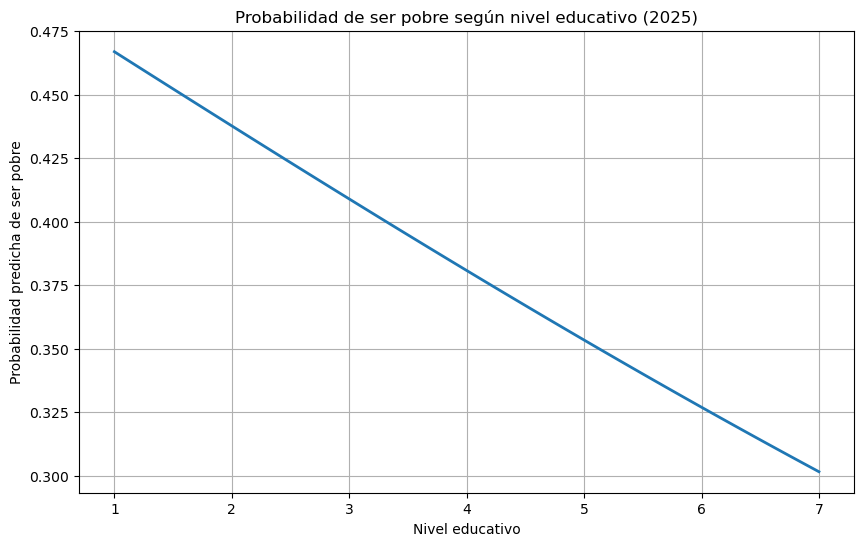

In [50]:
# =========================================
# CONSIGNA 4: Gráfico de la probabilidad predicha
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tomamos el dataset 2025 limpio para graficar
resp_2025_clean = resp_2025[variables_X + ['pobre']].dropna().copy()

# 1) Crear un vector con valores de la variable elegida (nivel_ed)
x_vals = np.linspace(resp_2025_clean['nivel_ed'].min(),
                     resp_2025_clean['nivel_ed'].max(), 100)

# 2) Crear un dataframe con todos los regresores para predecir
df_pred = pd.DataFrame({
    'const': 1,
    'ch06': resp_2025_clean['ch06'].mean(),
    'nivel_ed': x_vals,
    'estado': resp_2025_clean['estado'].mean(),
    'cat_inac': resp_2025_clean['cat_inac'].mean(),
    'cat_ocup': resp_2025_clean['cat_ocup'].mean(),
    'pp10a': resp_2025_clean['pp10a'].mean(),
    'p21': resp_2025_clean['p21'].mean(),
    't_vi': resp_2025_clean['t_vi'].mean(),
    'adulto_esquiv': resp_2025_clean['adulto_esquiv'].mean(),
    'ad_equiv_hogar': resp_2025_clean['ad_equiv_hogar'].mean()
})

# 3) Calcular probabilidad predicha
df_pred['prob_pobre'] = resultado.predict(df_pred)

# 4) Graficar
plt.figure(figsize=(10,6))
plt.plot(x_vals, df_pred['prob_pobre'], linewidth=2)
plt.xlabel("Nivel educativo")
plt.ylabel("Probabilidad predicha de ser pobre")
plt.title("Probabilidad de ser pobre según nivel educativo (2025)")
plt.grid(True)
plt.show()


PARTE C. Método de Vecinos Cercanos (KNN)

Consigna 5

In [51]:
variables_knn = variables_X.copy()   # mismas variables que para el logit
variables_knn.append('pobre')

# Hacemos train con SOLO esas variables
train_knn = pd.concat([X_train_2025, y_train_2025], axis=1)

# Eliminamos solo filas donde falten datos relevantes
train_knn = train_knn.dropna(subset=variables_knn)

# Reconstruimos X y y limpios
X_train_knn = train_knn[X_train_2025.columns]
y_train_knn = train_knn['pobre']

print("Filas disponibles para KNN:", X_train_knn.shape[0])


Filas disponibles para KNN: 6086


In [52]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

K_values = [1, 5, 10]
resultados_knn = {}

for k in K_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_knn)

    y_pred = knn.predict(X_train_knn)
    acc = accuracy_score(y_train_knn, y_pred)

    resultados_knn[k] = acc
    print(f"K={k}: Accuracy (train) = {acc:.4f}")


K=1: Accuracy (train) = 0.9839
K=5: Accuracy (train) = 0.7718
K=10: Accuracy (train) = 0.7291


Consigna 6

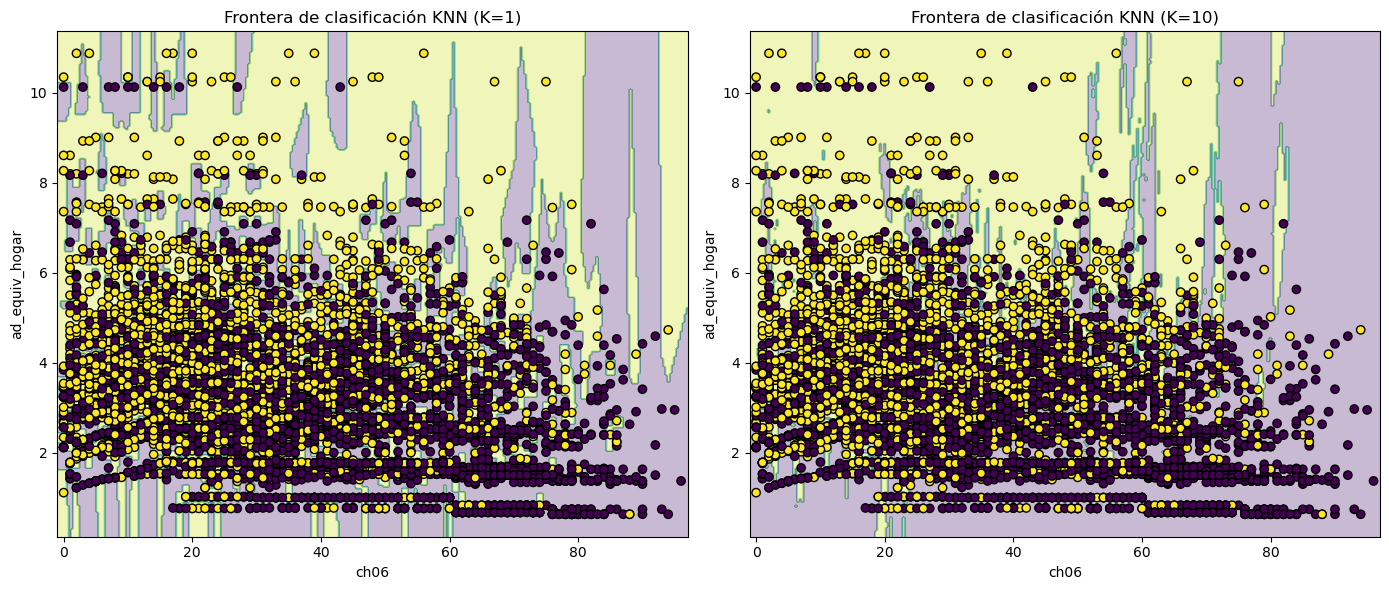

In [53]:
# ==================================
# 6) Visualización de fronteras KNN
# ==================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Seleccionar dos variables numéricas
var1 = "ch06"
var2 = "ad_equiv_hogar"

X_plot = X_train_knn[[var1, var2]].values
y_plot = y_train_knn.values

# Crear una malla para dibujar la frontera
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

fig, axes = plt.subplots(1, 2, figsize=(14,6))

for ax, k in zip(axes, [1, 10]):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_plot, y_plot)

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap='viridis', edgecolors='k')
    ax.set_title(f"Frontera de clasificación KNN (K={k})")
    ax.set_xlabel(var1)
    ax.set_ylabel(var2)

plt.tight_layout()
plt.show()


Consigna 7

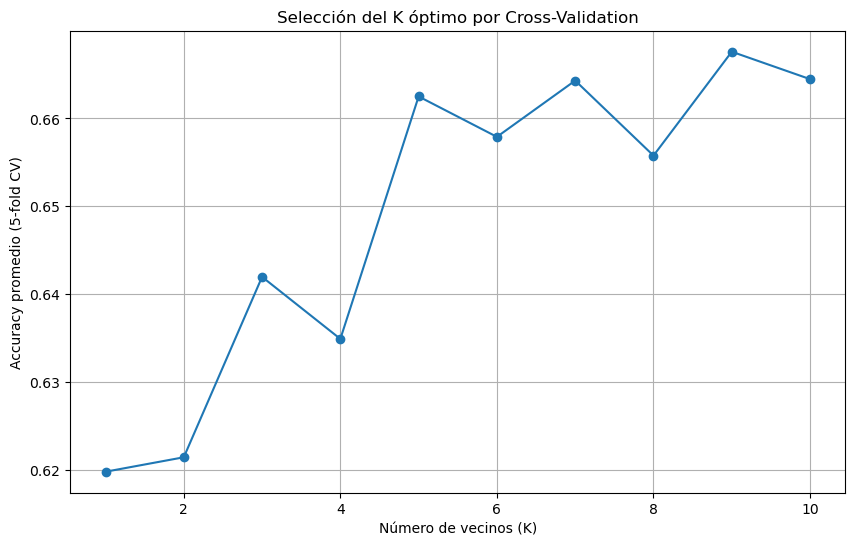

➡️ El K óptimo por 5-fold CV es: 9


In [54]:
# ==========================================
# 7) Selección de K óptimo por 5-fold CV
# ==========================================

from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

K_range = range(1, 11)
cv_scores = []

kf = KFold(n_splits=5, shuffle=True, random_state=444)

for k in K_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, 
                             X_train_knn, 
                             y_train_knn,
                             cv=kf, 
                             scoring='accuracy')
    cv_scores.append(scores.mean())

# Gráfico del accuracy por K
plt.figure(figsize=(10,6))
plt.plot(K_range, cv_scores, marker='o')
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy promedio (5-fold CV)")
plt.title("Selección del K óptimo por Cross-Validation")
plt.grid(True)
plt.show()

best_k = K_range[np.argmax(cv_scores)]
print(f"➡️ El K óptimo por 5-fold CV es: {best_k}")


Parte D. Desempeño de modelos afuera de la muestra, métricas y politicas públicas

Consigna 8

1. MATRIZ DE CONFUSIÓN — LOGIT (umbral p > 0.5)

In [55]:
from sklearn.metrics import confusion_matrix

# Predicción con LOGIT en test
y_pred_logit_prob = resultado.predict(X_test_2025)
y_pred_logit = (y_pred_logit_prob > 0.5).astype(int)

cm_logit = confusion_matrix(y_test_2025, y_pred_logit)
cm_logit


array([[1022,  409],
       [ 391,  787]])

2. CURVA ROC — LOGIT vs KNN (K óptimo)

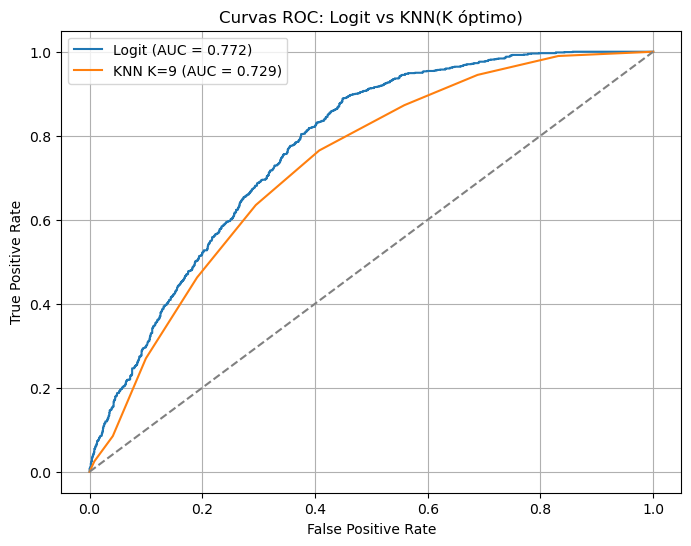

In [56]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Entrenar KNN con K óptimo
knn_cv = KNeighborsClassifier(n_neighbors=best_k)
knn_cv.fit(X_train_knn, y_train_knn)

# Probabilidades para curva ROC (en KNN es proporción de vecinos)
y_pred_knn_prob = knn_cv.predict_proba(X_test_2025)[:,1]

# ROC Logit
fpr_logit, tpr_logit, _ = roc_curve(y_test_2025, y_pred_logit_prob)
roc_auc_logit = auc(fpr_logit, tpr_logit)

# ROC KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test_2025, y_pred_knn_prob)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8,6))
plt.plot(fpr_logit, tpr_logit, label=f"Logit (AUC = {roc_auc_logit:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN K={best_k} (AUC = {roc_auc_knn:.3f})")
plt.plot([0,1], [0,1], '--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC: Logit vs KNN(K óptimo)")
plt.legend()
plt.grid(True)
plt.show()


3. TABLA DE MÉTRICAS (Accuracy – F1 – Recall – Precision)

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

metricas = pd.DataFrame({
    "Modelo": ["Logit", f"KNN (K={best_k})"],
    "Accuracy": [
        accuracy_score(y_test_2025, y_pred_logit),
        accuracy_score(y_test_2025, knn_cv.predict(X_test_2025))
    ],
    "Precision": [
        precision_score(y_test_2025, y_pred_logit),
        precision_score(y_test_2025, knn_cv.predict(X_test_2025))
    ],
    "Recall": [
        recall_score(y_test_2025, y_pred_logit),
        recall_score(y_test_2025, knn_cv.predict(X_test_2025))
    ],
    "F1-score": [
        f1_score(y_test_2025, y_pred_logit),
        f1_score(y_test_2025, knn_cv.predict(X_test_2025))
    ]
})

metricas


,Modelo,Accuracy,Precision,Recall,F1-score
0,Logit,0.693369,0.658027,0.668081,0.663016
1,KNN (K=9),0.673438,0.639316,0.634975,0.637138
